In [1]:
import os
import pandas as pd
import numpy as np
from pathlib import Path

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
BASE_DIR = Path.cwd()

print("Project directory:")
print(BASE_DIR)

Project directory:
c:\Users\dell\OneDrive\Desktop\IMAGES


In [3]:
CONVID_DIR = BASE_DIR / "ConViD — Concrete Visual Defect Dataset"

STRUCTURAL_DIR = (
    BASE_DIR
    / "STRUCTURAL_DEFECT_DATASET"
    / "03_ANNOTATED"
)

print("ConViD dataset:")
print(CONVID_DIR)

print("\nStructural defect dataset:")
print(STRUCTURAL_DIR)

ConViD dataset:
c:\Users\dell\OneDrive\Desktop\IMAGES\ConViD — Concrete Visual Defect Dataset

Structural defect dataset:
c:\Users\dell\OneDrive\Desktop\IMAGES\STRUCTURAL_DEFECT_DATASET\03_ANNOTATED


In [4]:
print("ConViD exists:", CONVID_DIR.exists())
print("Structural dataset exists:", STRUCTURAL_DIR.exists())

ConViD exists: True
Structural dataset exists: True


In [5]:
print("ConViD folders:")
for item in CONVID_DIR.iterdir():
    if item.is_dir():
        print(" -", item.name)

print("\nStructural dataset folders:")
for item in STRUCTURAL_DIR.iterdir():
    if item.is_dir():
        print(" -", item.name)

ConViD folders:
 - crack
 - Honeycomb
 - Spalling

Structural dataset folders:
 - CRACKS IMAGES AND LABELS
 - HONEYCOMB IMAGES AND LABELS
 - SPALLING IMAGES AND LABELS


In [6]:
IMAGE_EXTENSIONS = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".webp"
}

def get_image_files(folder):
    """Return all image files inside a folder and its subfolders."""
    return [
        file
        for file in Path(folder).rglob("*")
        if file.is_file() and file.suffix.lower() in IMAGE_EXTENSIONS
    ]


def count_images(folder):
    return len(get_image_files(folder))

In [7]:
# ConViD counts

convid_crack = count_images(CONVID_DIR / "crack")
convid_honeycomb = count_images(CONVID_DIR / "Honeycomb")
convid_spalling = count_images(CONVID_DIR / "Spalling")
convid_void = count_images(CONVID_DIR / "VOID")

print("CONVID DATASET")
print("----------------")
print("Crack     :", convid_crack)
print("Honeycomb :", convid_honeycomb)
print("Spalling  :", convid_spalling)
print("VOID      :", convid_void)

CONVID DATASET
----------------
Crack     : 365
Honeycomb : 511
Spalling  : 576
VOID      : 0


In [8]:
# Structural dataset counts

struct_crack = count_images(
    STRUCTURAL_DIR / "CRACKS IMAGES AND LABELS"
)

struct_honeycomb = count_images(
    STRUCTURAL_DIR / "HONEYCOMB IMAGES AND LABELS"
)

struct_spalling = count_images(
    STRUCTURAL_DIR / "SPALLING IMAGES AND LABELS"
)

print("STRUCTURAL DEFECT DATASET")
print("--------------------------")
print("Crack     :", struct_crack)
print("Honeycomb :", struct_honeycomb)
print("Spalling  :", struct_spalling)

STRUCTURAL DEFECT DATASET
--------------------------
Crack     : 7307
Honeycomb : 1869
Spalling  : 650


In [9]:
summary = pd.DataFrame({
    "Class": ["Crack", "Honeycomb", "Spalling"],
    "ConViD": [
        convid_crack,
        convid_honeycomb,
        convid_spalling
    ],
    "Structural": [
        struct_crack,
        struct_honeycomb,
        struct_spalling
    ]
})

summary["Total"] = summary["ConViD"] + summary["Structural"]

print(summary.to_string(index=False))

print("\nTotal images:",
      summary["Total"].sum())

    Class  ConViD  Structural  Total
    Crack     365        7307   7672
Honeycomb     511        1869   2380
 Spalling     576         650   1226

Total images: 11278


In [10]:
all_image_files = []

for folder in [
    CONVID_DIR / "crack",
    CONVID_DIR / "Honeycomb",
    CONVID_DIR / "Spalling",
    STRUCTURAL_DIR / "CRACKS IMAGES AND LABELS",
    STRUCTURAL_DIR / "HONEYCOMB IMAGES AND LABELS",
    STRUCTURAL_DIR / "SPALLING IMAGES AND LABELS"
]:
    all_image_files.extend(get_image_files(folder))

extensions = pd.Series(
    [file.suffix.lower() for file in all_image_files]
).value_counts()

print(extensions)

.jpg    11278
Name: count, dtype: int64


In [ ]:
#CREATE MASTER DATAFRAME

records = []

# Class configuration
class_mapping = {
    "crack": 0,
    "honeycomb": 1,
    "spalling": 2
}

# ------------------------------------------------------------
# CONVID DATASET
# ------------------------------------------------------------

convid_folders = {
    "crack": CONVID_DIR / "crack",
    "honeycomb": CONVID_DIR / "Honeycomb",
    "spalling": CONVID_DIR / "Spalling"
}

for class_name, folder in convid_folders.items():

    for image_path in get_image_files(folder):

        records.append({
            "image_path": str(image_path),
            "class": class_name,
            "class_id": class_mapping[class_name],
            "source": "ConViD"
        })


# ------------------------------------------------------------
# STRUCTURAL DEFECT DATASET
# ------------------------------------------------------------

structural_folders = {
    "crack": STRUCTURAL_DIR / "CRACKS IMAGES AND LABELS",
    "honeycomb": STRUCTURAL_DIR / "HONEYCOMB IMAGES AND LABELS",
    "spalling": STRUCTURAL_DIR / "SPALLING IMAGES AND LABELS"
}

for class_name, folder in structural_folders.items():

    for image_path in get_image_files(folder):

        records.append({
            "image_path": str(image_path),
            "class": class_name,
            "class_id": class_mapping[class_name],
            "source": "Structural"
        })


# ------------------------------------------------------------
# CREATE DATAFRAME
# ------------------------------------------------------------

df = pd.DataFrame(records)

print("Total images:", len(df))

df.head()

Total images: 11278


,image_path,class,class_id,source
0,c:\Users\dell\OneDrive\Desktop\IMAGES\ConViD —...,crack,0,ConViD
1,c:\Users\dell\OneDrive\Desktop\IMAGES\ConViD —...,crack,0,ConViD
2,c:\Users\dell\OneDrive\Desktop\IMAGES\ConViD —...,crack,0,ConViD
3,c:\Users\dell\OneDrive\Desktop\IMAGES\ConViD —...,crack,0,ConViD
4,c:\Users\dell\OneDrive\Desktop\IMAGES\ConViD —...,crack,0,ConViD


In [12]:
print("CLASS DISTRIBUTION")
print("==================")

print(df["class"].value_counts())

print("\nPercent distribution:")
print(
    (df["class"].value_counts(normalize=True) * 100)
    .round(2)
)

CLASS DISTRIBUTION
class
crack        7672
honeycomb    2380
spalling     1226
Name: count, dtype: int64

Percent distribution:
class
crack        68.03
honeycomb    21.10
spalling     10.87
Name: proportion, dtype: float64


In [13]:
print("SOURCE DISTRIBUTION")
print("===================")

print(df["source"].value_counts())

print("\nClass × Source:")
print(
    pd.crosstab(
        df["class"],
        df["source"]
    )
)

SOURCE DISTRIBUTION
source
Structural    9826
ConViD        1452
Name: count, dtype: int64

Class × Source:
source     ConViD  Structural
class                        
crack         365        7307
honeycomb     511        1869
spalling      576         650


In [14]:
duplicate_paths = df["image_path"].duplicated().sum()

print("Duplicate paths:", duplicate_paths)

Duplicate paths: 0


In [15]:
MASTER_CSV = BASE_DIR / "master_dataset.csv"

df.to_csv(
    MASTER_CSV,
    index=False
)

print("Master dataset saved to:")
print(MASTER_CSV)

Master dataset saved to:
c:\Users\dell\OneDrive\Desktop\IMAGES\master_dataset.csv


In [16]:
!pip install -q pillow


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [17]:
from PIL import Image

bad_images = []
valid_images = []

for image_path in df["image_path"]:

    try:
        with Image.open(image_path) as img:
            img.verify()

        valid_images.append(image_path)

    except Exception as e:
        bad_images.append({
            "image_path": image_path,
            "error": str(e)
        })

print("Total images:", len(df))
print("Valid images:", len(valid_images))
print("Corrupted images:", len(bad_images))

Total images: 11278
Valid images: 11278
Corrupted images: 0


In [18]:
image_info = []

for image_path in df["image_path"]:

    try:
        with Image.open(image_path) as img:

            image_info.append({
                "image_path": image_path,
                "width": img.width,
                "height": img.height,
                "mode": img.mode,
                "format": img.format
            })

    except:
        pass


image_info_df = pd.DataFrame(image_info)

print(image_info_df.head())

                                          image_path  width  height mode  \
0  c:\Users\dell\OneDrive\Desktop\IMAGES\ConViD —...   3056    3056  RGB   
1  c:\Users\dell\OneDrive\Desktop\IMAGES\ConViD —...   3056    3056  RGB   
2  c:\Users\dell\OneDrive\Desktop\IMAGES\ConViD —...   3056    3056  RGB   
3  c:\Users\dell\OneDrive\Desktop\IMAGES\ConViD —...   3056    3056  RGB   
4  c:\Users\dell\OneDrive\Desktop\IMAGES\ConViD —...   3056    3056  RGB   

  format  
0   JPEG  
1   JPEG  
2   JPEG  
3   JPEG  
4   JPEG  


In [19]:
print("IMAGE MODES")
print("===========")

print(image_info_df["mode"].value_counts())

IMAGE MODES
mode
RGB    11278
Name: count, dtype: int64


In [20]:
print("IMAGE WIDTH")
print("============")
print(image_info_df["width"].describe())

print("\nIMAGE HEIGHT")
print("============")
print(image_info_df["height"].describe())

IMAGE WIDTH
count    11278.000000
mean       905.024295
std        920.277360
min        224.000000
25%        224.000000
50%        640.000000
75%        768.000000
max       4080.000000
Name: width, dtype: float64

IMAGE HEIGHT
count    11278.000000
mean       906.415145
std        948.147428
min        224.000000
25%        224.000000
50%        640.000000
75%        768.000000
max       4080.000000
Name: height, dtype: float64


In [21]:
import hashlib

def calculate_hash(image_path):
    hash_md5 = hashlib.md5()

    with open(image_path, "rb") as f:

        for chunk in iter(lambda: f.read(8192), b""):
            hash_md5.update(chunk)

    return hash_md5.hexdigest()

In [22]:
hashes = []

for image_path in df["image_path"]:

    try:
        hashes.append(
            calculate_hash(image_path)
        )

    except:
        hashes.append(None)


df["image_hash"] = hashes

print("Images processed:", len(df))

Images processed: 11278


In [23]:
duplicate_hashes = (
    df[df["image_hash"].notna()]
    .groupby("image_hash")
    .filter(lambda x: len(x) > 1)
)

print(
    "Images involved in exact duplicates:",
    len(duplicate_hashes)
)

Images involved in exact duplicates: 626


In [24]:
duplicate_groups = (
    df[df["image_hash"].notna()]
    .groupby("image_hash")
    .size()
)

print(
    "Number of duplicate groups:",
    (duplicate_groups > 1).sum()
)

Number of duplicate groups: 313


In [25]:
print(df.columns)

Index(['image_path', 'class', 'class_id', 'source', 'image_hash'], dtype='object')


In [ ]:
# REMOVE EXACT DUPLICATES


print("Original images:", len(df))

# Keep the first occurrence of every exact image
df_clean = df.drop_duplicates(
    subset="image_hash",
    keep="first"
).copy()

print("After removing exact duplicates:", len(df_clean))
print("Removed:", len(df) - len(df_clean))

Original images: 11278
After removing exact duplicates: 10965
Removed: 313


In [ ]:
# REMOVE CORRUPTED IMAGES


bad_paths = set(
    item["image_path"]
    for item in bad_images
)

df_clean = df_clean[
    ~df_clean["image_path"].isin(bad_paths)
].copy()

print("Clean images:", len(df_clean))

Clean images: 10965


In [28]:
print(df_clean["class"].value_counts())

class
crack        7360
honeycomb    2380
spalling     1225
Name: count, dtype: int64


In [29]:
!pip install -q scikit-learn
from sklearn.model_selection import train_test_split


train_df, temp_df = train_test_split(
    df_clean,
    test_size=0.30,
    stratify=df_clean["class_id"],
    random_state=42
)

print("Training:", len(train_df))
print("Temporary:", len(temp_df))


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Training: 7675
Temporary: 3290


In [30]:
# VALIDATION / TEST SPLIT

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["class_id"],
    random_state=42
)

print("Training   :", len(train_df))
print("Validation :", len(val_df))
print("Testing    :", len(test_df))

Training   : 7675
Validation : 1645
Testing    : 1645


In [31]:
# CHECK CLASS DISTRIBUTION

def show_distribution(name, data):

    print(f"\n{name}")
    print("=" * len(name))

    counts = data["class"].value_counts()
    percentages = (
        data["class"].value_counts(normalize=True) * 100
    )

    distribution = pd.DataFrame({
        "Count": counts,
        "Percentage": percentages.round(2)
    })

    print(distribution)


show_distribution("TRAINING SET", train_df)
show_distribution("VALIDATION SET", val_df)
show_distribution("TEST SET", test_df)


TRAINING SET
           Count  Percentage
class                       
crack       5152       67.13
honeycomb   1666       21.71
spalling     857       11.17

VALIDATION SET
           Count  Percentage
class                       
crack       1104       67.11
honeycomb    357       21.70
spalling     184       11.19

TEST SET
           Count  Percentage
class                       
crack       1104       67.11
honeycomb    357       21.70
spalling     184       11.19


In [32]:
train_df = train_df.copy()
val_df = val_df.copy()
test_df = test_df.copy()

train_df["split"] = "train"
val_df["split"] = "validation"
test_df["split"] = "test"

In [33]:
master_split_df = pd.concat(
    [
        train_df,
        val_df,
        test_df
    ],
    ignore_index=True
)

print(master_split_df["split"].value_counts())

split
train         7675
validation    1645
test          1645
Name: count, dtype: int64


In [34]:
SPLIT_CSV = BASE_DIR / "wall_defect_dataset_split.csv"

master_split_df.to_csv(
    SPLIT_CSV,
    index=False
)

print("Saved:")
print(SPLIT_CSV)

Saved:
c:\Users\dell\OneDrive\Desktop\IMAGES\wall_defect_dataset_split.csv


In [35]:
!pip install -q tensorflow scikit-learn pandas pillow matplotlib seaborn

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-ai-generativelanguage 0.6.15 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0dev,>=3.20.2, but you have protobuf 7.35.1 which is incompatible.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 7.35.1 which is incompatible.
streamlit 1.49.1 requires pillow<12,>=7.1.0, but you have pillow 12.3.0 which is incompatible.
streamlit 1.49.1 requires protobuf<7,>=3.20, but you have protobuf 7.35.1 which is incompatible.

[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [37]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from PIL import Image

import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.21.0
GPU available: []


In [38]:
feature_extractor = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    pooling="avg"
)

feature_extractor.trainable = False

print("EfficientNetB0 loaded successfully!")

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
EfficientNetB0 loaded successfully!


In [39]:
feature_extractor.summary()

Model: "efficientnetb0"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, None,      │          0 │ -                 │
│ (InputLayer)        │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, None,      │          0 │ input_layer[0][0] │
│ (Rescaling)         │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, None,      │          7 │ rescaling[0][0]   │
│ (Normalization)     │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, None,      │          0 │ normalization[0]… │
│ (Rescaling)         │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, None,      │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, None,      │        864 │ stem_conv_pad[0]… │
│                     │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, None,      │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, None,      │          0 │ stem_bn[0][0]     │
│ (Activation)        │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, None,      │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, None,      │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, None,      │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, None,      │          0 │ block1a_activati… │
│ (Multiply)          │ None, 32)         │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, None,      │        512 │ block1a_se_excit

 Total params: 4,049,571 (15.45 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 4,049,571 (15.45 MB)

In [40]:
sample_path = train_df.iloc[0]["image_path"]

print("Sample image:")
print(sample_path)

img = Image.open(sample_path).convert("RGB")

print("Original size:", img.size)

img_resized = img.resize((224, 224))

img_array = np.array(img_resized)

print("Array shape:", img_array.shape)

img_array = np.expand_dims(img_array, axis=0)

print("Batch shape:", img_array.shape)

Sample image:
c:\Users\dell\OneDrive\Desktop\IMAGES\STRUCTURAL_DEFECT_DATASET\03_ANNOTATED\CRACKS IMAGES AND LABELS\Odisha_05926.jpg
Original size: (224, 224)
Array shape: (224, 224, 3)
Batch shape: (1, 224, 224, 3)


In [41]:
features = feature_extractor.predict(
    img_array,
    verbose=0
)

print("Feature shape:", features.shape)

Feature shape: (1, 1280)


In [42]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

def load_and_preprocess_image(image_path):
    """
    Load an image, convert it to RGB,
    resize it to 224x224, and return a NumPy array.
    """
    
    img = Image.open(image_path).convert("RGB")
    img = img.resize(IMG_SIZE)

    img_array = np.array(img, dtype=np.float32)

    return img_array

In [43]:
sample_image = load_and_preprocess_image(
    train_df.iloc[0]["image_path"]
)

print("Shape:", sample_image.shape)
print("Data type:", sample_image.dtype)
print("Minimum:", sample_image.min())
print("Maximum:", sample_image.max())

Shape: (224, 224, 3)
Data type: float32
Minimum: 0.0
Maximum: 189.0


In [44]:
def create_batches(dataframe, batch_size=32):
    """
    Generate batches of images and their corresponding labels.
    """

    paths = dataframe["image_path"].tolist()
    labels = dataframe["class_id"].tolist()

    for start in range(0, len(paths), batch_size):

        batch_paths = paths[start:start + batch_size]
        batch_labels = labels[start:start + batch_size]

        images = []

        for path in batch_paths:
            try:
                image = load_and_preprocess_image(path)
                images.append(image)

            except Exception as e:
                print(f"Could not load: {path}")
                print("Error:", e)

        if len(images) == 0:
            continue

        yield (
            np.array(images, dtype=np.float32),
            np.array(batch_labels[:len(images)])
        )

In [45]:
batch_images, batch_labels = next(
    create_batches(train_df, batch_size=32)
)

print("Images:", batch_images.shape)
print("Labels:", batch_labels.shape)

Images: (32, 224, 224, 3)
Labels: (32,)


In [46]:
batch_features = feature_extractor.predict(
    batch_images,
    verbose=0
)

print("Features:", batch_features.shape)

Features: (32, 1280)


In [47]:
def extract_features(dataframe, model, batch_size=32):
    """
    Extract EfficientNetB0 features for all images
    in a dataframe.
    """

    all_features = []
    all_labels = []
    valid_paths = []

    total = len(dataframe)

    for start in range(0, total, batch_size):

        batch_df = dataframe.iloc[start:start + batch_size]

        images = []
        labels = []
        paths = []

        for _, row in batch_df.iterrows():

            try:
                image = load_and_preprocess_image(
                    row["image_path"]
                )

                images.append(image)
                labels.append(row["class_id"])
                paths.append(row["image_path"])

            except Exception as e:

                print(
                    f"Skipping image: {row['image_path']}"
                )

                print("Error:", e)

        if not images:
            continue

        images = np.array(
            images,
            dtype=np.float32
        )

        features = model.predict(
            images,
            verbose=0
        )

        all_features.append(features)
        all_labels.extend(labels)
        valid_paths.extend(paths)

        print(
            f"Processed {min(start + batch_size, total)} "
            f"/ {total}"
        )

    return (
        np.vstack(all_features),
        np.array(all_labels),
        valid_paths
    )

In [48]:
X_train, y_train, train_paths = extract_features(
    train_df,
    feature_extractor,
    batch_size=BATCH_SIZE
)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

Processed 32 / 7675
Processed 64 / 7675
Processed 96 / 7675
Processed 128 / 7675
Processed 160 / 7675
Processed 192 / 7675
Processed 224 / 7675
Processed 256 / 7675
Processed 288 / 7675
Processed 320 / 7675
Processed 352 / 7675
Processed 384 / 7675
Processed 416 / 7675
Processed 448 / 7675
Processed 480 / 7675
Processed 512 / 7675
Processed 544 / 7675
Processed 576 / 7675
Processed 608 / 7675
Processed 640 / 7675
Processed 672 / 7675
Processed 704 / 7675
Processed 736 / 7675
Processed 768 / 7675
Processed 800 / 7675
Processed 832 / 7675
Processed 864 / 7675
Processed 896 / 7675
Processed 928 / 7675
Processed 960 / 7675
Processed 992 / 7675
Processed 1024 / 7675
Processed 1056 / 7675
Processed 1088 / 7675
Processed 1120 / 7675
Processed 1152 / 7675
Processed 1184 / 7675
Processed 1216 / 7675
Processed 1248 / 7675
Processed 1280 / 7675
Processed 1312 / 7675
Processed 1344 / 7675
Processed 1376 / 7675
Processed 1408 / 7675
Processed 1440 / 7675
Processed 1472 / 7675
Processed 1504 / 7675


In [49]:
X_val, y_val, val_paths = extract_features(
    val_df,
    feature_extractor,
    batch_size=BATCH_SIZE
)

print("X_val shape:", X_val.shape)
print("y_val shape:", y_val.shape)

Processed 32 / 1645
Processed 64 / 1645
Processed 96 / 1645
Processed 128 / 1645
Processed 160 / 1645
Processed 192 / 1645
Processed 224 / 1645
Processed 256 / 1645
Processed 288 / 1645
Processed 320 / 1645
Processed 352 / 1645
Processed 384 / 1645
Processed 416 / 1645
Processed 448 / 1645
Processed 480 / 1645
Processed 512 / 1645
Processed 544 / 1645
Processed 576 / 1645
Processed 608 / 1645
Processed 640 / 1645
Processed 672 / 1645
Processed 704 / 1645
Processed 736 / 1645
Processed 768 / 1645
Processed 800 / 1645
Processed 832 / 1645
Processed 864 / 1645
Processed 896 / 1645
Processed 928 / 1645
Processed 960 / 1645
Processed 992 / 1645
Processed 1024 / 1645
Processed 1056 / 1645
Processed 1088 / 1645
Processed 1120 / 1645
Processed 1152 / 1645
Processed 1184 / 1645
Processed 1216 / 1645
Processed 1248 / 1645
Processed 1280 / 1645
Processed 1312 / 1645
Processed 1344 / 1645
Processed 1376 / 1645
Processed 1408 / 1645
Processed 1440 / 1645
Processed 1472 / 1645
Processed 1504 / 1645


In [50]:
X_test, y_test, test_paths = extract_features(
    test_df,
    feature_extractor,
    batch_size=BATCH_SIZE
)

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

Processed 32 / 1645
Processed 64 / 1645
Processed 96 / 1645
Processed 128 / 1645
Processed 160 / 1645
Processed 192 / 1645
Processed 224 / 1645
Processed 256 / 1645
Processed 288 / 1645
Processed 320 / 1645
Processed 352 / 1645
Processed 384 / 1645
Processed 416 / 1645
Processed 448 / 1645
Processed 480 / 1645
Processed 512 / 1645
Processed 544 / 1645
Processed 576 / 1645
Processed 608 / 1645
Processed 640 / 1645
Processed 672 / 1645
Processed 704 / 1645
Processed 736 / 1645
Processed 768 / 1645
Processed 800 / 1645
Processed 832 / 1645
Processed 864 / 1645
Processed 896 / 1645
Processed 928 / 1645
Processed 960 / 1645
Processed 992 / 1645
Processed 1024 / 1645
Processed 1056 / 1645
Processed 1088 / 1645
Processed 1120 / 1645
Processed 1152 / 1645
Processed 1184 / 1645
Processed 1216 / 1645
Processed 1248 / 1645
Processed 1280 / 1645
Processed 1312 / 1645
Processed 1344 / 1645
Processed 1376 / 1645
Processed 1408 / 1645
Processed 1440 / 1645
Processed 1472 / 1645
Processed 1504 / 1645


In [79]:
#SAVE EFFICIENTNET FEATURES AS JSON

import json
from pathlib import Path

# ------------------------------------------------------------
# 1. CREATE / RESET FEATURES FOLDER
# ------------------------------------------------------------

FEATURE_DIR = BASE_DIR / "features"
FEATURE_DIR.mkdir(exist_ok=True)

# ------------------------------------------------------------
# 2. FUNCTION TO CONVERT FEATURES INTO JSON RECORDS
# ------------------------------------------------------------

def create_feature_records(X, y):
    
    records = []

    for features, label in zip(X, y):
        
        records.append({
            "features": features.tolist(),
            "class_id": int(label)
        })
    
    return records


# ------------------------------------------------------------
# 3. TRAINING FEATURES
# ------------------------------------------------------------

train_records = create_feature_records(
    X_train,
    y_train
)

with open(
    FEATURE_DIR / "efficientnet_train_features.json",
    "w"
) as f:
    
    json.dump(
        train_records,
        f
    )


# ------------------------------------------------------------
# 4. VALIDATION FEATURES
# ------------------------------------------------------------

val_records = create_feature_records(
    X_val,
    y_val
)

with open(
    FEATURE_DIR / "efficientnet_val_features.json",
    "w"
) as f:
    
    json.dump(
        val_records,
        f
    )


# ------------------------------------------------------------
# 5. TEST FEATURES
# ------------------------------------------------------------

test_records = create_feature_records(
    X_test,
    y_test
)

with open(
    FEATURE_DIR / "efficientnet_test_features.json",
    "w"
) as f:
    
    json.dump(
        test_records,
        f
    )


# ------------------------------------------------------------
# 6. VERIFY FILES
# ------------------------------------------------------------

print("JSON feature files saved successfully!\n")

print("Features folder:")
print(FEATURE_DIR)

print("\nFiles created:")

for file in FEATURE_DIR.iterdir():
    print(" -", file.name)

print("\nRecord counts:")
print("Train      :", len(train_records))
print("Validation :", len(val_records))
print("Test       :", len(test_records))

JSON feature files saved successfully!

Features folder:
c:\Users\dell\OneDrive\Desktop\IMAGES\features

Files created:
 - efficientnet_test_features.json
 - efficientnet_train_features.json
 - efficientnet_val_features.json

Record counts:
Train      : 7675
Validation : 1645
Test       : 1645


In [52]:
print(train_features_df.shape)
print(val_features_df.shape)
print(test_features_df.shape)

(7675, 1281)
(1645, 1281)
(1645, 1281)


In [53]:
train_features_df.head()

,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,...,feature_1271,feature_1272,feature_1273,feature_1274,feature_1275,feature_1276,feature_1277,feature_1278,feature_1279,class_id
0,0.004885,-0.155982,-0.197580,-0.150906,-0.141916,-0.012733,-0.125507,-0.184257,-0.097943,0.237723,...,-0.205183,-0.105801,-0.138628,-0.131511,0.963522,-0.022889,-0.082683,0.700680,0.435918,0
1,0.155388,-0.012286,-0.109728,-0.053654,-0.207476,-0.170144,0.738305,-0.180115,0.852353,-0.009201,...,-0.053649,-0.066433,-0.098106,-0.189559,0.057732,-0.129136,-0.082682,-0.171360,0.179352,0
2,0.247603,-0.086545,0.006959,0.107761,-0.120010,-0.092651,0.636533,-0.083588,0.006734,0.137631,...,0.162659,-0.151896,-0.113073,0.508934,-0.181307,-0.117388,-0.104810,-0.025727,1.018504,1
3,0.356726,-0.151351,-0.154690,0.388835,-0.161045,0.633336,-0.095986,0.209610,-0.212429,0.382459,...,-0.097942,-0.165321,0.509559,1.149177,-0.186668,-0.058257,-0.084289,-0.119244,0.101289,1
4,-0.158336,-0.066811,-0.182699,-0.133944,-0.076764,-0.034971,0.294476,-0.154380,-0.194756,-0.143363,...,-0.090290,-0.127864,-0.219576,0.083836,-0.202460,-0.050177,-0.092312,0.981017,-0.207161,0


In [54]:
X_train_ml = train_features_df[feature_columns]
y_train_ml = train_features_df["class_id"]

X_val_ml = val_features_df[feature_columns]
y_val_ml = val_features_df["class_id"]

X_test_ml = test_features_df[feature_columns]
y_test_ml = test_features_df["class_id"]

print("Training:", X_train_ml.shape)
print("Validation:", X_val_ml.shape)
print("Testing:", X_test_ml.shape)

Training: (7675, 1280)
Validation: (1645, 1280)
Testing: (1645, 1280)


In [55]:
# LOGISTIC REGRESSION


logistic_model = LogisticRegression(
    max_iter=2000,
    random_state=42
)

logistic_model.fit(
    X_train_ml,
    y_train_ml
)

print("Logistic Regression trained successfully!")

Logistic Regression trained successfully!


In [56]:
y_val_pred_lr = logistic_model.predict(
    X_val_ml
)

y_val_prob_lr = logistic_model.predict_proba(
    X_val_ml
)

In [57]:
from sklearn.metrics import accuracy_score

lr_val_accuracy = accuracy_score(
    y_val_ml,
    y_val_pred_lr
)

print(
    f"Logistic Regression Validation Accuracy: "
    f"{lr_val_accuracy * 100:.2f}%"
)

Logistic Regression Validation Accuracy: 99.03%


In [58]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_val_ml,
        y_val_pred_lr,
        target_names=[
            "Crack",
            "Honeycomb",
            "Spalling"
        ]
    )
)

              precision    recall  f1-score   support

       Crack       1.00      1.00      1.00      1104
   Honeycomb       0.98      0.99      0.98       357
    Spalling       0.99      0.92      0.96       184

    accuracy                           0.99      1645
   macro avg       0.99      0.97      0.98      1645
weighted avg       0.99      0.99      0.99      1645



In [59]:
cm_lr = confusion_matrix(
    y_val_ml,
    y_val_pred_lr
)

print(cm_lr)

[[1104    0    0]
 [   0  355    2]
 [   5    9  170]]


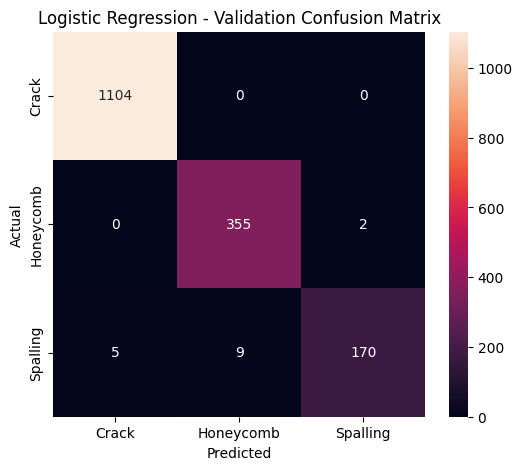

In [61]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt="d",
    xticklabels=[
        "Crack",
        "Honeycomb",
        "Spalling"
    ],
    yticklabels=[
        "Crack",
        "Honeycomb",
        "Spalling"
    ]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression - Validation Confusion Matrix")

plt.show()

In [67]:
# ============================================================
# RANDOM FOREST — IMPORTS
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score
)

print("Random Forest libraries imported successfully!")

Random Forest libraries imported successfully!


In [68]:
# ============================================================
# RANDOM FOREST — TRAINING
# ============================================================

random_forest_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

random_forest_model.fit(
    X_train_ml,
    y_train_ml
)

print("Random Forest trained successfully!")

Random Forest trained successfully!


In [69]:
# ============================================================
# RANDOM FOREST — VALIDATION PREDICTIONS
# ============================================================

y_val_pred_rf = random_forest_model.predict(
    X_val_ml
)

print("Validation predictions generated!")

Validation predictions generated!


In [70]:
# ============================================================
# RANDOM FOREST — VALIDATION ACCURACY
# ============================================================

rf_val_accuracy = accuracy_score(
    y_val_ml,
    y_val_pred_rf
)

print(
    f"Random Forest Validation Accuracy: "
    f"{rf_val_accuracy * 100:.2f}%"
)

Random Forest Validation Accuracy: 96.60%


In [71]:
# ============================================================
# RANDOM FOREST — CLASSIFICATION REPORT
# ============================================================

rf_report = classification_report(
    y_val_ml,
    y_val_pred_rf,
    target_names=[
        "Crack",
        "Honeycomb",
        "Spalling"
    ]
)

print(rf_report)

              precision    recall  f1-score   support

       Crack       0.98      1.00      0.99      1104
   Honeycomb       0.92      0.98      0.95       357
    Spalling       0.99      0.74      0.85       184

    accuracy                           0.97      1645
   macro avg       0.96      0.91      0.93      1645
weighted avg       0.97      0.97      0.96      1645



In [72]:
# ============================================================
# RANDOM FOREST — MACRO F1
# ============================================================

rf_f1 = f1_score(
    y_val_ml,
    y_val_pred_rf,
    average="macro"
)

print(
    f"Random Forest Macro F1: "
    f"{rf_f1:.4f}"
)

Random Forest Macro F1: 0.9288


In [73]:
# ============================================================
# RANDOM FOREST — CONFUSION MATRIX
# ============================================================

cm_rf = confusion_matrix(
    y_val_ml,
    y_val_pred_rf
)

print("Confusion Matrix:")
print(cm_rf)

Confusion Matrix:
[[1103    1    0]
 [   6  350    1]
 [  20   28  136]]


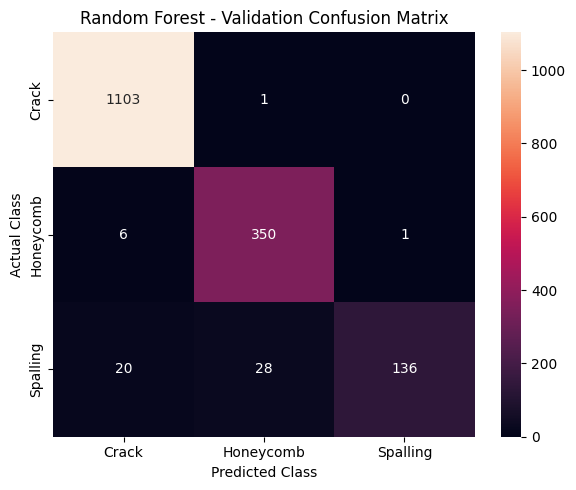

In [74]:
# ============================================================
# RANDOM FOREST — CONFUSION MATRIX VISUALIZATION
# ============================================================

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    xticklabels=[
        "Crack",
        "Honeycomb",
        "Spalling"
    ],
    yticklabels=[
        "Crack",
        "Honeycomb",
        "Spalling"
    ]
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Random Forest - Validation Confusion Matrix")

plt.tight_layout()
plt.show()

In [76]:
# ============================================================
# MODEL COMPARISON
# ============================================================

from sklearn.metrics import accuracy_score, f1_score
import pandas as pd

# Logistic Regression predictions
y_val_pred_lr = logistic_model.predict(X_val_ml)

# Random Forest predictions
y_val_pred_rf = random_forest_model.predict(X_val_ml)

# Logistic Regression metrics
lr_accuracy = accuracy_score(
    y_val_ml,
    y_val_pred_lr
)

lr_f1 = f1_score(
    y_val_ml,
    y_val_pred_lr,
    average="macro"
)

# Random Forest metrics
rf_accuracy = accuracy_score(
    y_val_ml,
    y_val_pred_rf
)

rf_f1 = f1_score(
    y_val_ml,
    y_val_pred_rf,
    average="macro"
)

# Comparison table
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Validation Accuracy (%)": [
        lr_accuracy * 100,
        rf_accuracy * 100
    ],
    "Macro F1 (%)": [
        lr_f1 * 100,
        rf_f1 * 100
    ]
})

comparison.round(2)

,Model,Validation Accuracy (%),Macro F1 (%)
0,Logistic Regression,99.03,97.92
1,Random Forest,96.60,92.88


In [77]:
print("RANDOM FOREST CLASSIFICATION REPORT")
print("=" * 45)

print(
    classification_report(
        y_val_ml,
        y_val_pred_rf,
        target_names=[
            "Crack",
            "Honeycomb",
            "Spalling"
        ]
    )
)

RANDOM FOREST CLASSIFICATION REPORT
              precision    recall  f1-score   support

       Crack       0.98      1.00      0.99      1104
   Honeycomb       0.92      0.98      0.95       357
    Spalling       0.99      0.74      0.85       184

    accuracy                           0.97      1645
   macro avg       0.96      0.91      0.93      1645
weighted avg       0.97      0.97      0.96      1645



In [81]:
!pip install -q joblib


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [82]:
# ============================================================
# SAVE LOGISTIC REGRESSION MODEL
# ============================================================

import joblib
from pathlib import Path

MODEL_DIR = BASE_DIR / "models"
MODEL_DIR.mkdir(exist_ok=True)

joblib.dump(
    logistic_model,
    MODEL_DIR / "logistic_regression_model.pkl"
)

print("Logistic Regression model saved successfully!")
print(MODEL_DIR / "logistic_regression_model.pkl")

Logistic Regression model saved successfully!
c:\Users\dell\OneDrive\Desktop\IMAGES\models\logistic_regression_model.pkl


In [83]:
# ============================================================
# SAVE EFFICIENTNET FEATURE EXTRACTOR
# ============================================================

feature_extractor.save(
    MODEL_DIR / "efficientnet_b0_feature_extractor.keras"
)

print("EfficientNetB0 saved successfully!")
print(
    MODEL_DIR /
    "efficientnet_b0_feature_extractor.keras"
)

EfficientNetB0 saved successfully!
c:\Users\dell\OneDrive\Desktop\IMAGES\models\efficientnet_b0_feature_extractor.keras


In [84]:
# ============================================================
# DECISION TREE
# ============================================================

from sklearn.tree import DecisionTreeClassifier

print("Decision Tree imported successfully!")

Decision Tree imported successfully!


In [85]:
decision_tree_model = DecisionTreeClassifier(
    random_state=42,
    class_weight="balanced"
)

decision_tree_model.fit(
    X_train_ml,
    y_train_ml
)

print("Decision Tree trained successfully!")

Decision Tree trained successfully!


In [86]:
# DECISION TREE — VALIDATION PREDICTIONS
# ============================================================

y_val_pred_dt = decision_tree_model.predict(
    X_val_ml
)

print("Validation predictions generated!")

Validation predictions generated!


In [87]:
# ============================================================
# DECISION TREE — VALIDATION ACCURACY
# ============================================================

dt_val_accuracy = accuracy_score(
    y_val_ml,
    y_val_pred_dt
)

print(
    f"Decision Tree Validation Accuracy: "
    f"{dt_val_accuracy * 100:.2f}%"
)

Decision Tree Validation Accuracy: 87.23%


In [88]:
# ============================================================
# DECISION TREE — CLASSIFICATION REPORT
# ============================================================

print("DECISION TREE — VALIDATION REPORT")
print("=" * 55)

print(
    classification_report(
        y_val_ml,
        y_val_pred_dt,
        target_names=[
            "Crack",
            "Honeycomb",
            "Spalling"
        ]
    )
)

DECISION TREE — VALIDATION REPORT
              precision    recall  f1-score   support

       Crack       0.93      0.95      0.94      1104
   Honeycomb       0.81      0.79      0.80       357
    Spalling       0.62      0.55      0.58       184

    accuracy                           0.87      1645
   macro avg       0.79      0.76      0.77      1645
weighted avg       0.87      0.87      0.87      1645



In [89]:
# ============================================================
# DECISION TREE — MACRO F1
# ============================================================

dt_val_f1 = f1_score(
    y_val_ml,
    y_val_pred_dt,
    average="macro"
)

print(
    f"Decision Tree Validation Macro F1: "
    f"{dt_val_f1 * 100:.2f}%"
)

Decision Tree Validation Macro F1: 77.39%


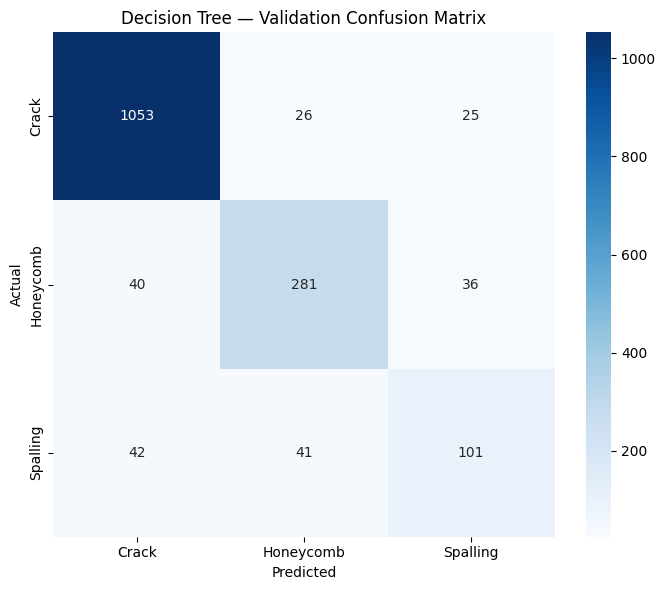

In [90]:
# ============================================================
# DECISION TREE — CONFUSION MATRIX
# ============================================================

cm_dt = confusion_matrix(
    y_val_ml,
    y_val_pred_dt
)

plt.figure(figsize=(7, 6))

sns.heatmap(
    cm_dt,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "Crack",
        "Honeycomb",
        "Spalling"
    ],
    yticklabels=[
        "Crack",
        "Honeycomb",
        "Spalling"
    ]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Decision Tree — Validation Confusion Matrix")

plt.tight_layout()
plt.show()

In [91]:
# ============================================================
# MODEL COMPARISON
# ============================================================

comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Decision Tree"
    ],

    "Validation Accuracy (%)": [
        lr_val_accuracy * 100,
        rf_val_accuracy * 100,
        dt_val_accuracy * 100
    ],

    "Validation Macro F1 (%)": [
        lr_f1 * 100,
        rf_f1 * 100,
        dt_val_f1 * 100
    ]
})

comparison.round(2)

,Model,Validation Accuracy (%),Validation Macro F1 (%)
0,Logistic Regression,99.03,97.92
1,Random Forest,96.60,92.88
2,Decision Tree,87.23,77.39


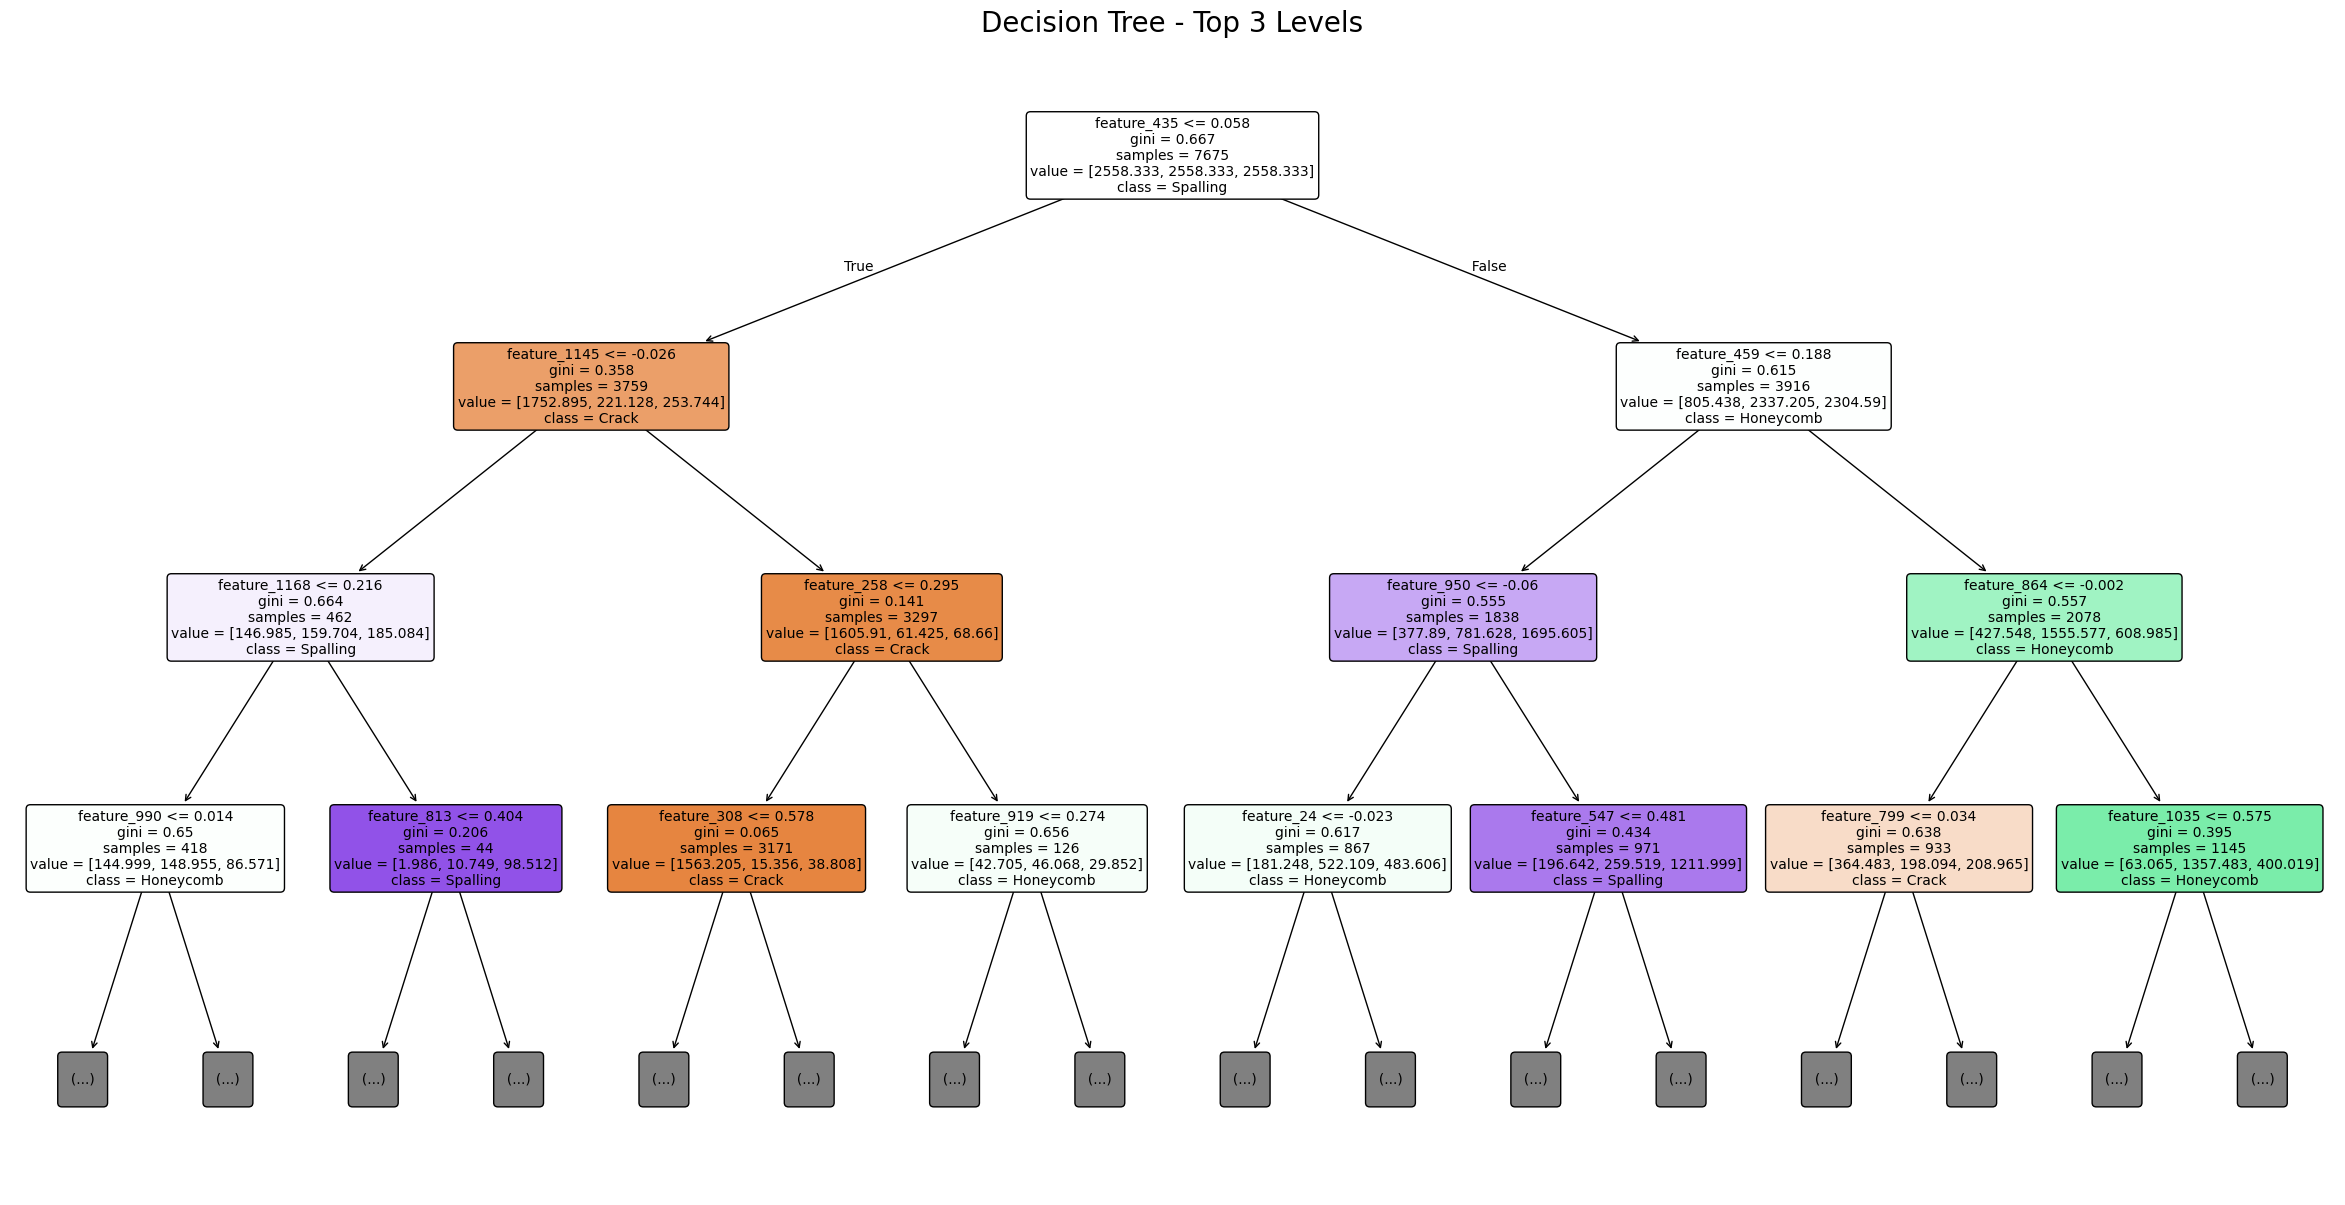

In [92]:
# ============================================================
# DECISION TREE VISUALIZATION
# ============================================================

from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(30, 15))

plot_tree(
    decision_tree_model,
    max_depth=3,
    feature_names=[
        f"feature_{i}"
        for i in range(X_train_ml.shape[1])
    ],
    class_names=[
        "Crack",
        "Honeycomb",
        "Spalling"
    ],
    filled=True,
    rounded=True,
    fontsize=10
)

plt.title(
    "Decision Tree - Top 3 Levels",
    fontsize=20
)

plt.show()

In [93]:
# ============================================================
# FEATURE IMPORTANCE
# ============================================================

feature_importance = pd.DataFrame({
    "Feature": [
        f"feature_{i}"
        for i in range(X_train_ml.shape[1])
    ],
    "Importance": decision_tree_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(20)

,Feature,Importance
435,feature_435,0.190457
459,feature_459,0.062775
1145,feature_1145,0.046175
864,feature_864,0.045886
1035,feature_1035,0.026261
950,feature_950,0.024922
799,feature_799,0.022496
547,feature_547,0.016907
24,feature_24,0.014432
1262,feature_1262,0.013087


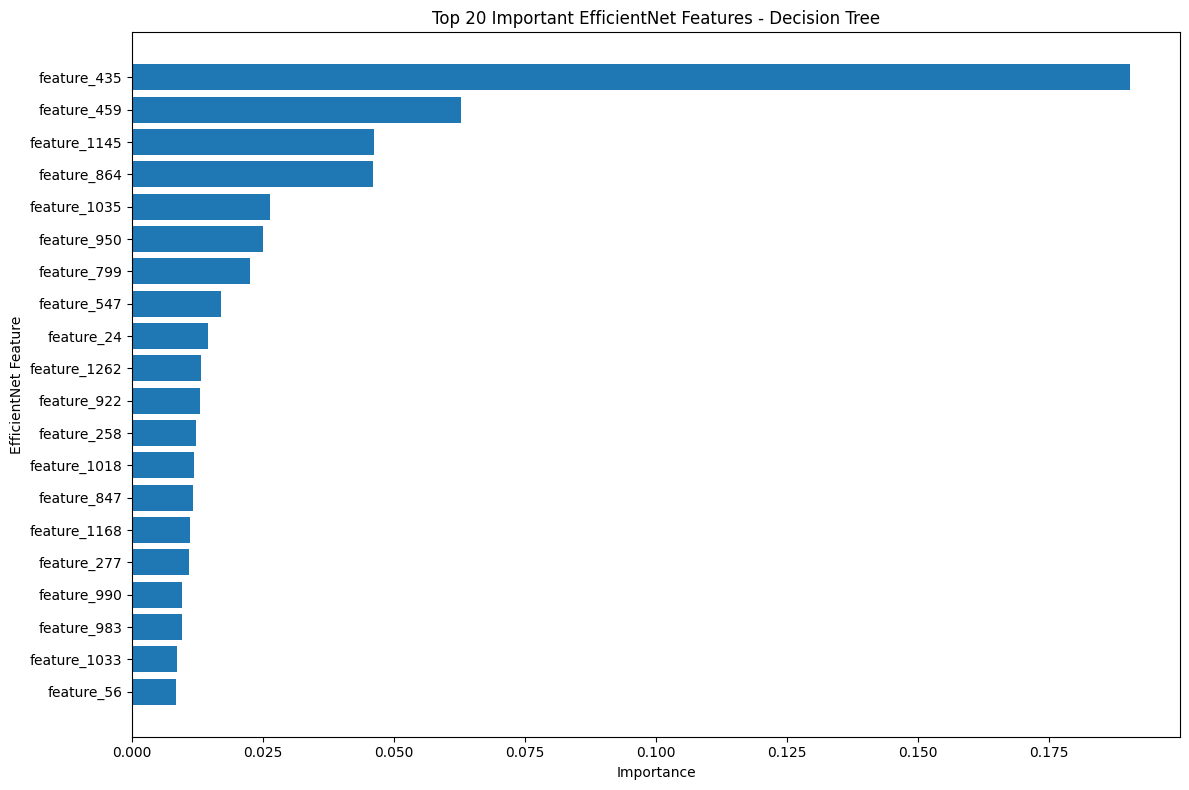

In [94]:
# ============================================================
# TOP 20 IMPORTANT FEATURES
# ============================================================

top_features = feature_importance.head(20)

plt.figure(figsize=(12, 8))

plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.xlabel("Importance")
plt.ylabel("EfficientNet Feature")
plt.title(
    "Top 20 Important EfficientNet Features - Decision Tree"
)

plt.tight_layout()
plt.show()

In [95]:
# ============================================================
# DECISION TREE RULES
# ============================================================

from sklearn.tree import export_text

tree_rules = export_text(
    decision_tree_model,
    feature_names=[
        f"feature_{i}"
        for i in range(X_train_ml.shape[1])
    ],
    max_depth=3
)

print(tree_rules)

|--- feature_435 <= 0.06
|   |--- feature_1145 <= -0.03
|   |   |--- feature_1168 <= 0.22
|   |   |   |--- feature_990 <= 0.01
|   |   |   |   |--- truncated branch of depth 8
|   |   |   |--- feature_990 >  0.01
|   |   |   |   |--- truncated branch of depth 6
|   |   |--- feature_1168 >  0.22
|   |   |   |--- feature_813 <= 0.40
|   |   |   |   |--- truncated branch of depth 3
|   |   |   |--- feature_813 >  0.40
|   |   |   |   |--- truncated branch of depth 3
|   |--- feature_1145 >  -0.03
|   |   |--- feature_258 <= 0.30
|   |   |   |--- feature_308 <= 0.58
|   |   |   |   |--- truncated branch of depth 8
|   |   |   |--- feature_308 >  0.58
|   |   |   |   |--- truncated branch of depth 3
|   |   |--- feature_258 >  0.30
|   |   |   |--- feature_919 <= 0.27
|   |   |   |   |--- truncated branch of depth 5
|   |   |   |--- feature_919 >  0.27
|   |   |   |   |--- truncated branch of depth 3
|--- feature_435 >  0.06
|   |--- feature_459 <= 0.19
|   |   |--- feature_950 <= -0.06
|  

In [96]:
# ============================================================
# TOP 20 DECISION TREE FEATURES
# ============================================================

top_20_features = feature_importance.head(20)

print(top_20_features.to_string(index=False))


# ============================================================
# DECISION TREE DEPTH & SIZE
# ============================================================

print("Tree Depth:", decision_tree_model.get_depth())
print("Number of Leaves:", decision_tree_model.get_n_leaves())
print("Total Nodes:", decision_tree_model.tree_.node_count)




     Feature  Importance
 feature_435    0.190457
 feature_459    0.062775
feature_1145    0.046175
 feature_864    0.045886
feature_1035    0.026261
 feature_950    0.024922
 feature_799    0.022496
 feature_547    0.016907
  feature_24    0.014432
feature_1262    0.013087
 feature_922    0.012997
 feature_258    0.012165
feature_1018    0.011895
 feature_847    0.011552
feature_1168    0.010966
 feature_277    0.010831
 feature_990    0.009569
 feature_983    0.009567
feature_1033    0.008563
  feature_56    0.008442
Tree Depth: 33
Number of Leaves: 377
Total Nodes: 753


In [97]:
# ============================================================
# DECISION TREE — TRAIN vs VALIDATION
# ============================================================

from sklearn.metrics import accuracy_score, f1_score

# Training predictions
y_train_pred_dt = decision_tree_model.predict(X_train_ml)

# Validation predictions
y_val_pred_dt = decision_tree_model.predict(X_val_ml)

# Accuracy
train_accuracy_dt = accuracy_score(
    y_train_ml,
    y_train_pred_dt
)

val_accuracy_dt = accuracy_score(
    y_val_ml,
    y_val_pred_dt
)

# Macro F1
train_f1_dt = f1_score(
    y_train_ml,
    y_train_pred_dt,
    average="macro"
)

val_f1_dt = f1_score(
    y_val_ml,
    y_val_pred_dt,
    average="macro"
)

print("DECISION TREE PERFORMANCE")
print("=" * 50)

print(f"Training Accuracy   : {train_accuracy_dt * 100:.2f}%")
print(f"Validation Accuracy : {val_accuracy_dt * 100:.2f}%")

print(f"\nTraining Macro F1   : {train_f1_dt * 100:.2f}%")
print(f"Validation Macro F1 : {val_f1_dt * 100:.2f}%")

print(f"\nAccuracy Gap        : {(train_accuracy_dt - val_accuracy_dt) * 100:.2f}%")
print(f"Macro F1 Gap        : {(train_f1_dt - val_f1_dt) * 100:.2f}%")

DECISION TREE PERFORMANCE
Training Accuracy   : 100.00%
Validation Accuracy : 87.23%

Training Macro F1   : 100.00%
Validation Macro F1 : 77.39%

Accuracy Gap        : 12.77%
Macro F1 Gap        : 22.61%


In [98]:
# ============================================================
# CONTROLLED DECISION TREE EXPERIMENT
# ============================================================

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score
import pandas as pd

depths = [5, 7, 10, 15]

dt_results = []

for depth in depths:

    model = DecisionTreeClassifier(
        max_depth=depth,
        min_samples_split=20,
        min_samples_leaf=10,
        class_weight="balanced",
        random_state=42
    )

    model.fit(
        X_train_ml,
        y_train_ml
    )

    # Predictions
    train_pred = model.predict(X_train_ml)
    val_pred = model.predict(X_val_ml)

    # Metrics
    train_acc = accuracy_score(
        y_train_ml,
        train_pred
    )

    val_acc = accuracy_score(
        y_val_ml,
        val_pred
    )

    train_f1 = f1_score(
        y_train_ml,
        train_pred,
        average="macro"
    )

    val_f1 = f1_score(
        y_val_ml,
        val_pred,
        average="macro"
    )

    dt_results.append({
        "Max Depth": depth,
        "Train Accuracy": train_acc,
        "Validation Accuracy": val_acc,
        "Train Macro F1": train_f1,
        "Validation Macro F1": val_f1,
        "Actual Depth": model.get_depth(),
        "Leaves": model.get_n_leaves()
    })


# Convert results to DataFrame
dt_results_df = pd.DataFrame(dt_results)

print("CONTROLLED DECISION TREE RESULTS")
print("=" * 90)

print(
    dt_results_df.to_string(index=False)
)

CONTROLLED DECISION TREE RESULTS
 Max Depth  Train Accuracy  Validation Accuracy  Train Macro F1  Validation Macro F1  Actual Depth  Leaves
         5        0.826580             0.796960        0.758706             0.704320             5      29
         7        0.886906             0.828571        0.838479             0.739538             7      85
        10        0.915570             0.838298        0.881569             0.744543            10     150
        15        0.919088             0.840729        0.886255             0.746323            15     170


In [99]:
# ============================================================
# CONTROLLED DECISION TREE EXPERIMENT
# ============================================================

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score
import pandas as pd

depths = [5, 7, 10, 15]

dt_results = []

for depth in depths:

    model = DecisionTreeClassifier(
        max_depth=depth,
        min_samples_split=20,
        min_samples_leaf=10,
        class_weight="balanced",
        random_state=42
    )

    model.fit(
        X_train_ml,
        y_train_ml
    )

    # Predictions
    train_pred = model.predict(X_train_ml)
    val_pred = model.predict(X_val_ml)

    # Metrics
    train_acc = accuracy_score(
        y_train_ml,
        train_pred
    )

    val_acc = accuracy_score(
        y_val_ml,
        val_pred
    )

    train_f1 = f1_score(
        y_train_ml,
        train_pred,
        average="macro"
    )

    val_f1 = f1_score(
        y_val_ml,
        val_pred,
        average="macro"
    )

    dt_results.append({
        "Max Depth": depth,
        "Train Accuracy": train_acc,
        "Validation Accuracy": val_acc,
        "Train Macro F1": train_f1,
        "Validation Macro F1": val_f1,
        "Actual Depth": model.get_depth(),
        "Leaves": model.get_n_leaves()
    })


# Convert results to DataFrame
dt_results_df = pd.DataFrame(dt_results)

print("CONTROLLED DECISION TREE RESULTS")
print("=" * 90)

print(
    dt_results_df.to_string(index=False)
)

CONTROLLED DECISION TREE RESULTS
 Max Depth  Train Accuracy  Validation Accuracy  Train Macro F1  Validation Macro F1  Actual Depth  Leaves
         5        0.826580             0.796960        0.758706             0.704320             5      29
         7        0.886906             0.828571        0.838479             0.739538             7      85
        10        0.915570             0.838298        0.881569             0.744543            10     150
        15        0.919088             0.840729        0.886255             0.746323            15     170


In [100]:
# ============================================================
# DECISION TREE HYPERPARAMETER TUNING
# ============================================================

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score
import pandas as pd

configs = [
    (10, 5),
    (10, 10),
    (10, 20),
    (20, 5),
    (20, 10),
    (20, 20),
    (30, 5),
    (30, 10),
    (30, 20)
]

results = []

for min_split, min_leaf in configs:

    model = DecisionTreeClassifier(
        max_depth=15,
        min_samples_split=min_split,
        min_samples_leaf=min_leaf,
        class_weight="balanced",
        random_state=42
    )

    model.fit(X_train_ml, y_train_ml)

    train_pred = model.predict(X_train_ml)
    val_pred = model.predict(X_val_ml)

    results.append({
        "Min Split": min_split,
        "Min Leaf": min_leaf,
        "Train Accuracy": accuracy_score(
            y_train_ml, train_pred
        ),
        "Validation Accuracy": accuracy_score(
            y_val_ml, val_pred
        ),
        "Train Macro F1": f1_score(
            y_train_ml,
            train_pred,
            average="macro"
        ),
        "Validation Macro F1": f1_score(
            y_val_ml,
            val_pred,
            average="macro"
        ),
        "Actual Depth": model.get_depth(),
        "Leaves": model.get_n_leaves()
    })

results_df = pd.DataFrame(results)

print(results_df.to_string(index=False))

 Min Split  Min Leaf  Train Accuracy  Validation Accuracy  Train Macro F1  Validation Macro F1  Actual Depth  Leaves
        10         5        0.955309             0.869301        0.934697             0.779877            15     230
        10        10        0.919088             0.840729        0.886255             0.746323            15     170
        10        20        0.895114             0.840122        0.848416             0.744654            15     113
        20         5        0.943713             0.864438        0.918531             0.775268            15     190
        20        10        0.919088             0.840729        0.886255             0.746323            15     170
        20        20        0.895114             0.840122        0.848416             0.744654            15     113
        30         5        0.930293             0.859574        0.900071             0.770875            15     162
        30        10        0.911661             0.838906       

In [101]:
# ============================================================
# BEST DECISION TREE — CLASSIFICATION REPORT
# ============================================================

best_dt = DecisionTreeClassifier(
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42
)

best_dt.fit(X_train_ml, y_train_ml)

y_val_pred_best_dt = best_dt.predict(X_val_ml)

print("BEST DECISION TREE")
print("=" * 60)

print(
    classification_report(
        y_val_ml,
        y_val_pred_best_dt,
        target_names=[
            "Crack",
            "Honeycomb",
            "Spalling"
        ]
    )
)

BEST DECISION TREE
              precision    recall  f1-score   support

       Crack       0.96      0.93      0.94      1104
   Honeycomb       0.78      0.80      0.79       357
    Spalling       0.57      0.65      0.61       184

    accuracy                           0.87      1645
   macro avg       0.77      0.79      0.78      1645
weighted avg       0.88      0.87      0.87      1645



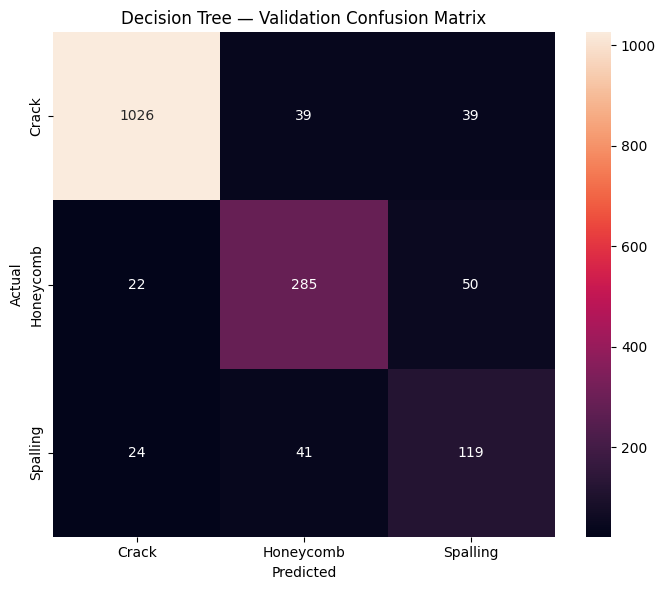

In [102]:
# ============================================================
# BEST DECISION TREE — CONFUSION MATRIX
# ============================================================

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(
    y_val_ml,
    y_val_pred_best_dt
)

plt.figure(figsize=(7, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Crack", "Honeycomb", "Spalling"],
    yticklabels=["Crack", "Honeycomb", "Spalling"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Decision Tree — Validation Confusion Matrix")

plt.tight_layout()
plt.show()

In [103]:
# ============================================================
# BEST DECISION TREE — FEATURE IMPORTANCE
# ============================================================

feature_names = [
    f"feature_{i}"
    for i in range(X_train_ml.shape[1])
]

best_dt_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": best_dt.feature_importances_
})

best_dt_importance = best_dt_importance.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

print("TOP 20 FEATURES")
print("=" * 50)

print(
    best_dt_importance.head(20).to_string(index=False)
)

TOP 20 FEATURES
     Feature  Importance
 feature_435    0.205471
 feature_459    0.068130
feature_1145    0.050114
 feature_864    0.049801
feature_1035    0.028501
 feature_950    0.027048
 feature_799    0.024415
 feature_547    0.017572
  feature_24    0.015664
feature_1262    0.014203
 feature_922    0.014106
 feature_258    0.013203
feature_1168    0.011902
 feature_277    0.011755
 feature_847    0.011714
feature_1018    0.011102
 feature_990    0.010386
feature_1033    0.009293
 feature_983    0.009198
 feature_628    0.009059


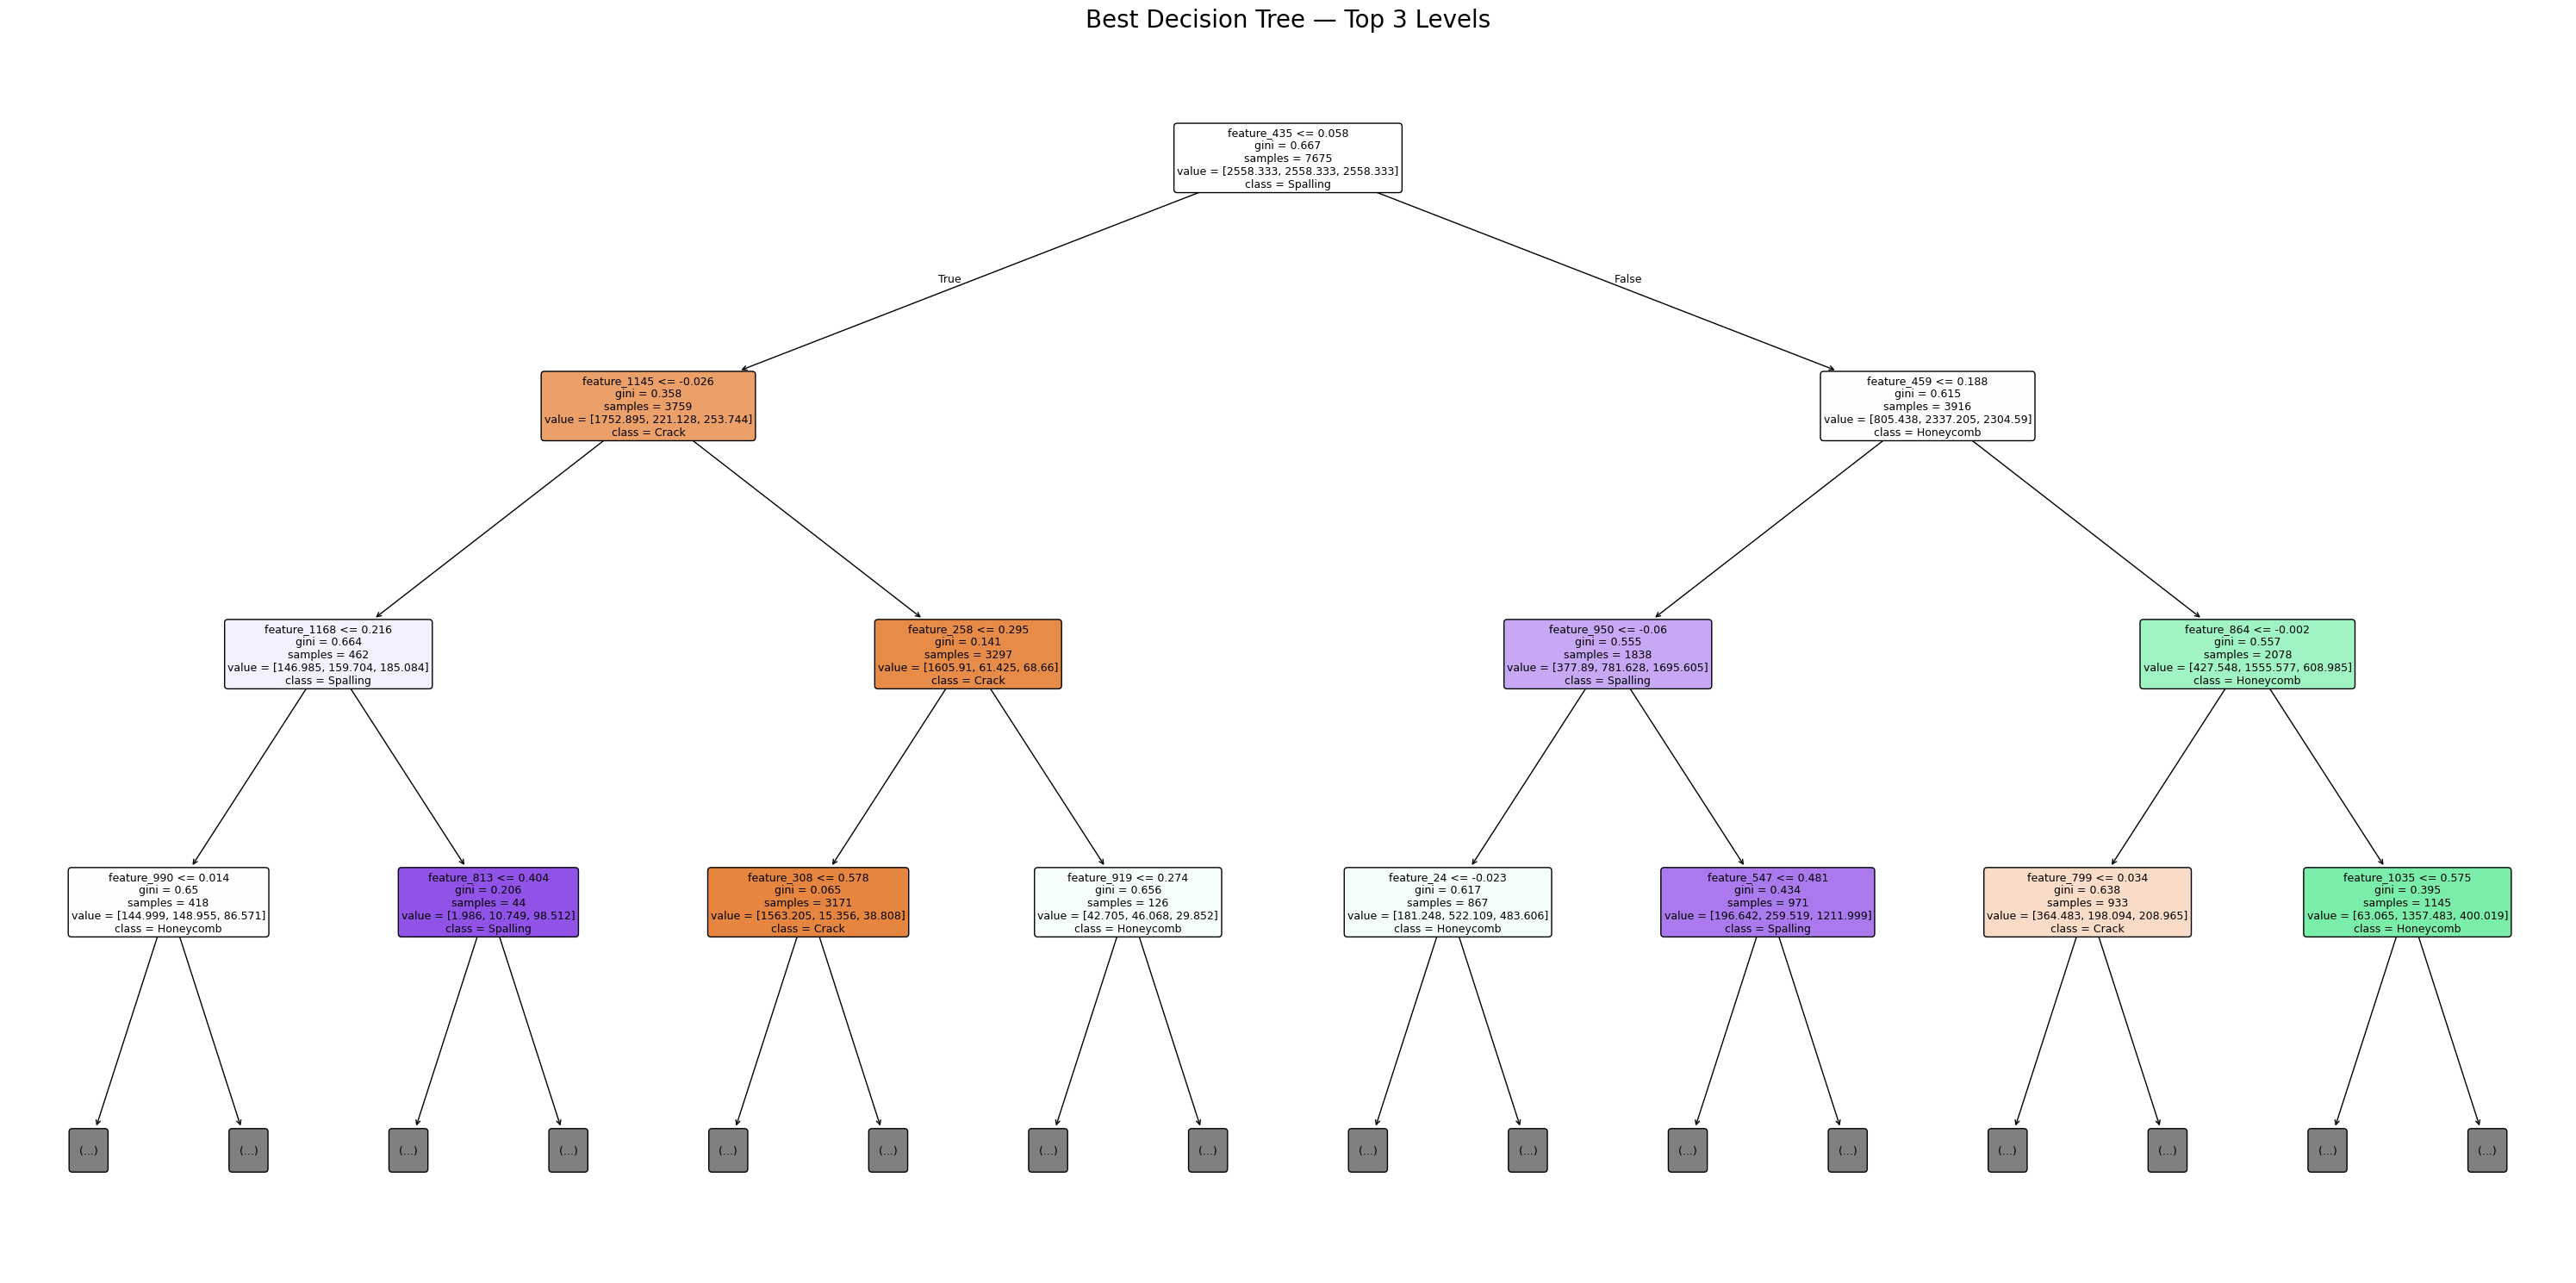

In [104]:
# ============================================================
# BEST DECISION TREE — VISUALIZATION
# ============================================================

from sklearn.tree import plot_tree

plt.figure(figsize=(30, 15))

plot_tree(
    best_dt,
    feature_names=feature_names,
    class_names=[
        "Crack",
        "Honeycomb",
        "Spalling"
    ],
    max_depth=3,
    filled=True,
    rounded=True,
    fontsize=9
)

plt.title(
    "Best Decision Tree — Top 3 Levels",
    fontsize=20
)

plt.tight_layout()
plt.show()

In [105]:
# ============================================================
# BEST TREE COMPLEXITY
# ============================================================

print("BEST DECISION TREE COMPLEXITY")
print("=" * 50)

print("Maximum Depth :", best_dt.get_depth())
print("Number of Leaves :", best_dt.get_n_leaves())
print("Total Nodes :", best_dt.tree_.node_count)

BEST DECISION TREE COMPLEXITY
Maximum Depth : 15
Number of Leaves : 230
Total Nodes : 459


In [106]:
# ============================================================
# BEST TREE — OVERFITTING CHECK
# ============================================================

train_pred = best_dt.predict(X_train_ml)
val_pred = best_dt.predict(X_val_ml)

train_acc = accuracy_score(
    y_train_ml,
    train_pred
)

val_acc = accuracy_score(
    y_val_ml,
    val_pred
)

train_f1 = f1_score(
    y_train_ml,
    train_pred,
    average="macro"
)

val_f1 = f1_score(
    y_val_ml,
    val_pred,
    average="macro"
)

print("FINAL OVERFITTING CHECK")
print("=" * 50)

print(f"Train Accuracy : {train_acc * 100:.2f}%")
print(f"Val Accuracy   : {val_acc * 100:.2f}%")

print(f"Train Macro F1 : {train_f1 * 100:.2f}%")
print(f"Val Macro F1   : {val_f1 * 100:.2f}%")

print(
    f"\nAccuracy Gap   : "
    f"{(train_acc - val_acc) * 100:.2f}%"
)

print(
    f"Macro F1 Gap   : "
    f"{(train_f1 - val_f1) * 100:.2f}%"
)

FINAL OVERFITTING CHECK
Train Accuracy : 95.53%
Val Accuracy   : 86.93%
Train Macro F1 : 93.47%
Val Macro F1   : 77.99%

Accuracy Gap   : 8.60%
Macro F1 Gap   : 15.48%


In [107]:
# ============================================================
# BEST TREE — OVERFITTING CHECK
# ============================================================

train_pred = best_dt.predict(X_train_ml)
val_pred = best_dt.predict(X_val_ml)

train_acc = accuracy_score(
    y_train_ml,
    train_pred
)

val_acc = accuracy_score(
    y_val_ml,
    val_pred
)

train_f1 = f1_score(
    y_train_ml,
    train_pred,
    average="macro"
)

val_f1 = f1_score(
    y_val_ml,
    val_pred,
    average="macro"
)

print("FINAL OVERFITTING CHECK")
print("=" * 50)

print(f"Train Accuracy : {train_acc * 100:.2f}%")
print(f"Val Accuracy   : {val_acc * 100:.2f}%")

print(f"Train Macro F1 : {train_f1 * 100:.2f}%")
print(f"Val Macro F1   : {val_f1 * 100:.2f}%")

print(
    f"\nAccuracy Gap   : "
    f"{(train_acc - val_acc) * 100:.2f}%"
)

print(
    f"Macro F1 Gap   : "
    f"{(train_f1 - val_f1) * 100:.2f}%"
)

FINAL OVERFITTING CHECK
Train Accuracy : 95.53%
Val Accuracy   : 86.93%
Train Macro F1 : 93.47%
Val Macro F1   : 77.99%

Accuracy Gap   : 8.60%
Macro F1 Gap   : 15.48%


In [108]:
# ============================================================
# FINAL MODEL COMPARISON — VALIDATION SET
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
import pandas as pd

# ------------------------------------------------------------
# 1. LOGISTIC REGRESSION
# ------------------------------------------------------------

y_val_pred_lr = logistic_model.predict(X_val_ml)

lr_accuracy = accuracy_score(y_val_ml, y_val_pred_lr)
lr_precision = precision_score(
    y_val_ml, y_val_pred_lr, average="macro"
)
lr_recall = recall_score(
    y_val_ml, y_val_pred_lr, average="macro"
)
lr_f1 = f1_score(
    y_val_ml, y_val_pred_lr, average="macro"
)


# ------------------------------------------------------------
# 2. RANDOM FOREST
# ------------------------------------------------------------

y_val_pred_rf = random_forest_model.predict(X_val_ml)

rf_accuracy = accuracy_score(y_val_ml, y_val_pred_rf)
rf_precision = precision_score(
    y_val_ml, y_val_pred_rf, average="macro"
)
rf_recall = recall_score(
    y_val_ml, y_val_pred_rf, average="macro"
)
rf_f1 = f1_score(
    y_val_ml, y_val_pred_rf, average="macro"
)


# ------------------------------------------------------------
# 3. DECISION TREE
# ------------------------------------------------------------

y_val_pred_dt = best_dt.predict(X_val_ml)

dt_accuracy = accuracy_score(y_val_ml, y_val_pred_dt)
dt_precision = precision_score(
    y_val_ml, y_val_pred_dt, average="macro"
)
dt_recall = recall_score(
    y_val_ml, y_val_pred_dt, average="macro"
)
dt_f1 = f1_score(
    y_val_ml, y_val_pred_dt, average="macro"
)


# ------------------------------------------------------------
# CREATE COMPARISON TABLE
# ------------------------------------------------------------

comparison_df = pd.DataFrame({

    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Decision Tree"
    ],

    "Accuracy": [
        lr_accuracy,
        rf_accuracy,
        dt_accuracy
    ],

    "Macro Precision": [
        lr_precision,
        rf_precision,
        dt_precision
    ],

    "Macro Recall": [
        lr_recall,
        rf_recall,
        dt_recall
    ],

    "Macro F1": [
        lr_f1,
        rf_f1,
        dt_f1
    ]
})


# Convert metrics to percentages
metric_columns = [
    "Accuracy",
    "Macro Precision",
    "Macro Recall",
    "Macro F1"
]

comparison_df[metric_columns] = (
    comparison_df[metric_columns] * 100
).round(2)


# Display
print("FINAL VALIDATION MODEL COMPARISON")
print("=" * 80)

print(
    comparison_df.to_string(index=False)
)

FINAL VALIDATION MODEL COMPARISON
              Model  Accuracy  Macro Precision  Macro Recall  Macro F1
Logistic Regression     99.03            98.64         97.28     97.92
      Random Forest     96.60            96.44         90.62     92.88
      Decision Tree     86.93            77.00         79.15     77.99
